# Sentiment Analysis on Twitter Data
**Internship Project — Codec Technologies (AI Internship)**

Goal: classify tweets as positive or negative using NLP + a classic ML classifier.

Dataset: NLTK's built-in `twitter_samples` corpus (5000 positive + 5000 negative tweets) — no external download/API key needed, works directly in Colab.

## 1. Setup — install & import libraries

In [1]:
import nltk
import re
import string
import pandas as pd
from nltk.corpus import twitter_samples, stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('twitter_samples')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## 2. Load the dataset

In [2]:
pos_tweets = twitter_samples.strings('positive_tweets.json')
neg_tweets = twitter_samples.strings('negative_tweets.json')

df = pd.DataFrame({
    'text': pos_tweets + neg_tweets,
    'label': [1]*len(pos_tweets) + [0]*len(neg_tweets)  # 1 = positive, 0 = negative
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
print(df.shape)
df.head()

(10000, 2)


,text,label
0,"I love you, how but you? @Taecyeon2pm8 did you...",0
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,1
2,"Your love, O Lord, is better than life. :) &lt...",1
3,@yasminyasir96 yeah but it will be better if w...,1
4,Ok good night I wish troye wasn't ugly and I m...,1


## 3. Clean the tweets

In [3]:
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+', '', text)                      # remove mentions
    text = re.sub(r'#', '', text)                          # remove hashtag symbol (keep word)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 1]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_tweet)
df[['text', 'clean_text']].head()

,text,clean_text
0,"I love you, how but you? @Taecyeon2pm8 did you...",love feel emm think
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,thanks guys
2,"Your love, O Lord, is better than life. :) &lt...",love lord better life lt3
3,@yasminyasir96 yeah but it will be better if w...,yeah better use official account like ❤️
4,Ok good night I wish troye wasn't ugly and I m...,ok good night wish troye wasnt ugly met today ...


## 4. Feature extraction (TF-IDF) & train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Train shape:', X_train_tfidf.shape)
print('Test shape:', X_test_tfidf.shape)

Train shape: (8000, 5000)
Test shape: (2000, 5000)


## 5. Train the model (Logistic Regression)

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.7515
              precision    recall  f1-score   support

    Negative       0.73      0.79      0.76       987
    Positive       0.78      0.71      0.74      1013

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000



## 6. Confusion matrix

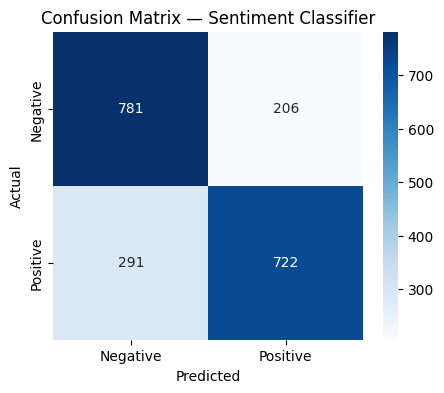

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Sentiment Classifier')
plt.show()

## 7. Try it on your own text

In [7]:
def predict_sentiment(text):
    cleaned = clean_tweet(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return 'Positive' if pred == 1 else 'Negative'

samples = [
    "I absolutely loved this movie, best day ever!",
    "This is the worst service I've ever experienced.",
    "Not sure how I feel about this update."
]
for s in samples:
    print(f'{s}  ->  {predict_sentiment(s)}')

I absolutely loved this movie, best day ever!  ->  Positive
This is the worst service I've ever experienced.  ->  Negative
Not sure how I feel about this update.  ->  Negative


## 8. Save model (optional — for deployment/demo)

In [8]:
import joblib
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print('Saved model + vectorizer — download these from the Colab file panel if you want them in your repo.')

Saved model + vectorizer — download these from the Colab file panel if you want them in your repo.
